In [41]:
!pip install -r ../requirements.txt

In [42]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## 1. Importação das bibliotecas

Nesta etapa, são importadas as bibliotecas utilizadas ao longo da análise, incluindo ferramentas para manipulação de dados e organização dos arquivos. Essa preparação garante um fluxo de trabalho consistente e reproduzível.

In [43]:
DATA_DIR = Path("../data")

arquivos = sorted(DATA_DIR.glob("data_*.csv"))
print(f"Arquivos encontrados: {[f.name for f in arquivos]}")

dfs = []
for arquivo in arquivos:
    df_temp = pd.read_csv(arquivo)
    df_temp["source_file"] = arquivo.name  
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print(f"Shape final: {df.shape}")
print(f"Colunas: {list(df.columns)}")

Arquivos encontrados: ['data_2018.csv', 'data_2019.csv', 'data_2020.csv', 'data_2021.csv', 'data_2022.csv']
Shape final: (8454383, 13)
Colunas: ['user_id', 'bill_id', 'line_item_amount', 'bill_discount', 'transaction_date', 'description', 'inventory_category', 'colour', 'size', 'zone_name', 'store_name', 'year', 'source_file']


## 2. Leitura e concatenação dos dados

Os cinco arquivos anuais são lidos e combinados em um único DataFrame. A consolidação facilita a análise conjunta da evolução das vendas entre 2018 e 2022.

In [44]:
df.head()

,user_id,bill_id,line_item_amount,bill_discount,transaction_date,description,inventory_category,colour,size,zone_name,store_name,year,source_file
0,403252497,401641461,1049.5,0.0,2018-08-11,TR ITA14TRK010 FF BROOKLYN STRAIGHT Beige 44 /...,TROUSER,Beige,44 / 112CM,East,East_7096,2018,data_2018.csv
1,357000026,397716483,659.4,0.0,2018-07-22,MB ITA14BLT016 35MM NA Olive Green 32 /,MB ITA14BLT016 35MM NA Olive Green 32 - 97CM,OLIVE GREEN,32 / 97CM,North,North_7018,2018,data_2018.csv
2,372773935,362298787,1899.0,0.0,2018-01-12,TR S15-NELSON FF KANSAS Tan 36 / 92CM,TROUSER,Tan,36 / 92CM,North,North_6505,2018,data_2018.csv
3,362714910,360637282,1799.0,0.0,2018-01-03,TR S15-BRANDON FF KANSAS Khaki 32 / 82CM,TROUSER,Khaki,32 / 82CM,North,North_6505,2018,data_2018.csv
4,393891557,374396867,1299.0,0.0,2018-03-29,MB ITA15BLT004 40MM NA Reddish Brown 38 / 112CM,ITA15BLT004-40MM,REDDISH BROWN,38 / 112CM,East,East_7310,2018,data_2018.csv


## 3. Inspeção inicial dos dados

As primeiras linhas e as informações estruturais do DataFrame são examinadas para entender o formato, os tipos de dados e as colunas disponíveis. Essa verificação inicial ajuda a identificar problemas que precisam ser tratados antes da análise.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8454383 entries, 0 to 8454382
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   user_id             int64  
 1   bill_id             int64  
 2   line_item_amount    float64
 3   bill_discount       float64
 4   transaction_date    object 
 5   description         object 
 6   inventory_category  object 
 7   colour              object 
 8   size                object 
 9   zone_name           object 
 10  store_name          object 
 11  year                int64  
 12  source_file         object 
dtypes: float64(2), int64(3), object(8)
memory usage: 838.5+ MB


In [46]:
print("Nulos")
print(df.isnull().sum())

print("\nduplicadas")
print(df.duplicated().sum())

print("\nDuplicatas por user_id + bill_id + description ")
print(df.duplicated(subset=["user_id", "bill_id", "description"]).sum())

Nulos
user_id                    0
bill_id                    0
line_item_amount           0
bill_discount              0
transaction_date           0
description               17
inventory_category    697444
colour                 15555
size                   15555
zone_name                  0
store_name                 0
year                       0
source_file                0
dtype: int64

duplicadas
1898076

Duplicatas por user_id + bill_id + description 
1963757


## 4. Qualidade: nulos e duplicatas

Esta célula verifica a existência de valores ausentes e registros duplicados, tanto no conjunto completo quanto na combinação de cliente, nota e descrição do item. O objetivo é distinguir erros de cadastro de repetições que podem representar compras legítimas.

In [47]:
duplicated_bills = df[df.duplicated(subset=["user_id", "bill_id", "description"], keep=False)]
print(f"Total de linhas envolvidas em duplicação: {len(duplicated_bills)}")

exemplo_bill = duplicated_bills["bill_id"].iloc[0]
df[df["bill_id"] == exemplo_bill]

Total de linhas envolvidas em duplicação: 3286725


,user_id,bill_id,line_item_amount,bill_discount,transaction_date,description,inventory_category,colour,size,zone_name,store_name,year,source_file
6,354576930,374735369,1880.816,0.0,2018-03-31,TWB S16-JACKSON FF BROOKLYN Khaki 34 / 87CM,MENS TROUSER WITH BELT,Khaki,34,East,East_7190,2018,data_2018.csv
7,354576930,374735369,1880.816,0.0,2018-03-31,TWB S16-JACKSON FF BROOKLYN Khaki 34 / 87CM,MENS TROUSER WITH BELT,Khaki,34,East,East_7190,2018,data_2018.csv
8,354576930,374735369,1880.816,0.0,2018-03-31,TWB S16-JACKSON FF BROOKLYN Khaki 34 / 87CM,MENS TROUSER WITH BELT,Khaki,34,East,East_7190,2018,data_2018.csv
9,354576930,374735369,1880.816,0.0,2018-03-31,TWB S16-JACKSON FF BROOKLYN Khaki 34 / 87CM,MENS TROUSER WITH BELT,Khaki,34,East,East_7190,2018,data_2018.csv
1408663,354576930,374735369,1724.016,0.0,2018-03-31,MTR A17-MADDEN FF URBAN Teak 32 / 82CM,MENS TROUSER,Teak,32,East,East_7190,2018,data_2018.csv
1408664,354576930,374735369,1724.016,0.0,2018-03-31,MTR A17-MADDEN FF URBAN Teak 32 / 82CM,MENS TROUSER,Teak,32,East,East_7190,2018,data_2018.csv
1408665,354576930,374735369,1724.016,0.0,2018-03-31,MTR A17-MADDEN FF URBAN Teak 32 / 82CM,MENS TROUSER,Teak,32,East,East_7190,2018,data_2018.csv
1408666,354576930,374735369,1724.016,0.0,2018-03-31,MTR A17-MADDEN FF URBAN Teak 32 / 82CM,MENS TROUSER,Teak,32,East,East_7190,2018,data_2018.csv


## 5. Investigação de duplicatas

Um exemplo de `bill_id` com registros repetidos é analisado em detalhe. Essa inspeção permite entender se as duplicatas são erros de dados ou se refletem diferentes unidades do mesmo produto em uma nota fiscal.

In [48]:
contagem_repeticoes = df.groupby(["user_id", "bill_id", "description"]).size()
print(contagem_repeticoes.value_counts().sort_index())

1      5167655
2       967622
3       226282
4        72847
5        24274
6        14706
7         5183
8         3961
9         2238
10        1936
11         382
12         891
13         158
14         761
15         367
16         152
17         108
18         133
19          31
20         249
21          74
22         254
23           2
24          54
25          24
26           2
27          14
28          40
29           3
30          39
31          74
32           8
33           2
34           2
35           7
36          15
37           1
38           3
39           2
40          23
42           4
43           1
44           2
45           2
46           1
47           1
48           5
49           3
53           1
54           1
55           1
60           8
62           3
68           1
80           1
108          1
116          1
120          2
Name: count, dtype: int64


## 6. Distribuição das repetições

A quantidade de ocorrências para cada combinação de cliente, nota e produto é analisada. Essa distribuição revela que a repetição de uma mesma linha pode funcionar como uma medida indireta da quantidade comprada.

**Achado:** as repetições não devem ser removidas automaticamente, pois podem representar compras de múltiplas unidades.

In [49]:
contagem = df.groupby(["user_id", "bill_id", "description"]).transform("size")
df["quantity_implicita"] = contagem

print(df[df["quantity_implicita"] >= 20][
    ["user_id", "bill_id", "description", "inventory_category", "quantity_implicita", "zone_name", "store_name", "transaction_date"]
].drop_duplicates().sort_values("quantity_implicita", ascending=False).head(20))

           user_id    bill_id  \
2877683  284131096  509006165   
2071325  416489066  440257468   
742677   401479529  395678249   
2217678  414657837  433627507   
6874296  408121042  701010303   
5055173  324320070  678669196   
1369164  389804390  364567016   
1369133  389804390  364607471   
1258007  389804390  364517647   
918564   413215023  428080048   
918544   413215023  428122352   
2877945    2749016  501327978   
6380306  408121042  701010303   
918504   413215023  428117778   
918514   413215023  428094237   
6318945  408121042  701010303   
918594   413215023  428090164   
6136     317186770  364601263   
3151137  467936764  596949796   
3151434  467936764  596949796   

                                               description  \
2877683                           EARN AND BURN GV500-2019   
2071325                CBG ITCBS00002 NA NA KHAKI 8X3X11.5   
742677                                CB REGULAR CARRY BAG   
2217678                 CBG ITCBR00001 NA NA KHAKI 12X4X16

## 7. Casos extremos de repetição

São investigados os grupos com muitas repetições da mesma combinação de cliente, nota e descrição. A análise mostra que os casos mais extremos estão frequentemente associados a itens não relacionados a roupas, como vales-presente e sacolas.

**Achado:** esses produtos apresentam um padrão de compra em lote diferente do comportamento esperado para peças de vestuário.

In [50]:
print("Zona")
print(df["zone_name"].value_counts())

mask_nao_roupa = df["description"].str.contains("EARN AND BURN|CARRY BAG", case=False, na=False)
print(f"\nLinhas de vale-presente/sacola: {mask_nao_roupa.sum()} ({mask_nao_roupa.mean()*100:.2f}%)")

print("\nquantity_implicita média: itens 'não-roupa' vs. roupas")
print(df.groupby(mask_nao_roupa)["quantity_implicita"].mean())

Zona
zone_name
South      5597570
North      1064971
West        954086
East        627788
ROOT        175777
Central      34191
Name: count, dtype: int64

Linhas de vale-presente/sacola: 103493 (1.22%)

quantity_implicita média: itens 'não-roupa' vs. roupas
description
False    1.807917
True     3.987275
Name: quantity_implicita, dtype: float64


## 8. Quantidade implícita

A coluna `quantity_implicita` é criada com base no número de ocorrências de cada combinação de cliente, nota e produto. Em seguida, as médias são comparadas entre itens de vestuário e itens não relacionados a roupas.

**Achado:** itens não-roupa apresentam quantidade média significativamente maior, confirmando que as repetições podem representar volume comprado.

In [51]:
df["is_apparel"] = ~df["description"].str.contains("EARN AND BURN|CARRY BAG", case=False, na=False)

print(df["is_apparel"].value_counts())
print(f"\n% não-apparel: {(~df['is_apparel']).mean()*100:.2f}%")

is_apparel
True     8350890
False     103493
Name: count, dtype: int64

% não-apparel: 1.22%


## 9. Classificação inicial de vestuário

É criada a flag `is_apparel`, classificando os registros com base em padrões encontrados na descrição do produto. Essa primeira versão serve como uma aproximação inicial para separar roupas de outros itens.

In [52]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

print(f"Datas nulas após conversão: {df['transaction_date'].isnull().sum()}")

df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.day_name()
df["quarter"] = df["transaction_date"].dt.quarter

print(f"\nData mínima: {df['transaction_date'].min()}")
print(f"Data máxima: {df['transaction_date'].max()}")

Datas nulas após conversão: 0

Data mínima: 2018-01-01 00:00:00
Data máxima: 2022-12-31 00:00:00


## 10. Tratamento das datas

A data da transação é convertida para um formato apropriado e decomposta em mês, dia da semana e trimestre. Essas novas variáveis permitem investigar tendências, sazonalidade e mudanças no comportamento de compra.

In [53]:
print(df["line_item_amount"].describe())
print(f"\nValores <= 0: {(df['line_item_amount'] <= 0).sum()}")
print(f"Valores negativos: {(df['line_item_amount'] < 0).sum()}")

print(df["bill_discount"].describe())
print(f"\nValores > 0 (com desconto): {(df['bill_discount'] > 0).sum()} ({(df['bill_discount'] > 0).mean()*100:.2f}%)")
print(f"Valores negativos: {(df['bill_discount'] < 0).sum()}")

count    8.454383e+06
mean     1.334790e+03
std      9.843195e+02
min      0.000000e+00
25%      6.990000e+02
50%      1.352693e+03
75%      1.999000e+03
max      6.410010e+05
Name: line_item_amount, dtype: float64

Valores <= 0: 8423
Valores negativos: 0
count    8.454383e+06
mean     9.284983e+01
std      8.119705e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.049536e+05
Name: bill_discount, dtype: float64

Valores > 0 (com desconto): 466489 (5.52%)
Valores negativos: 0


## 11. Validação dos valores financeiros

São avaliadas as distribuições de `line_item_amount` e `bill_discount`, incluindo estatísticas descritivas e a presença de valores zerados ou negativos. Essa etapa é necessária para verificar a consistência dos valores usados nos cálculos de receita e preço.

In [54]:
print(df.nlargest(10, "line_item_amount")[
    ["user_id", "bill_id", "description", "inventory_category", "line_item_amount", "quantity_implicita", "is_apparel", "zone_name"]
])

print("\n=== Top 10 bill_discount ===")
print(df.nlargest(10, "bill_discount")[
    ["user_id", "bill_id", "description", "line_item_amount", "bill_discount", "is_apparel", "zone_name"]
])

print("\n=== Amostra de line_item_amount == 0 ===")
print(df[df["line_item_amount"] == 0][["description", "inventory_category", "is_apparel"]].value_counts().head(10))

           user_id    bill_id                      description  \
1289440  325462042  390458433                              NaN   
109224   374599036  366854892                              NaN   
55511    350523848  361661266                              NaN   
8255018  245109959  754971321   MSH ITMSH01626 Slim LS White M   
8255019  245109959  754971321   MSH ITMSH01626 Slim LS White M   
8255020  245109959  755033270   MSH ITMSH01626 Slim LS White M   
8255021  245109959  755033270   MSH ITMSH01626 Slim LS White M   
6166214  245109959  755033270  MSH ITMSH01626 Slim LS White XL   
6166215  245109959  755033270  MSH ITMSH01626 Slim LS White XL   
6166216  245109959  754971321  MSH ITMSH01626 Slim LS White XL   

                      inventory_category  line_item_amount  \
1289440                              NaN          641001.0   
109224                               NaN          500070.0   
55511                                NaN          122002.0   
8255018   MSH ITMSH01626 

## 12. Investigação de valores extremos

Os maiores valores de venda e desconto são examinados, juntamente com exemplos de itens com valor zerado. O objetivo é identificar possíveis erros de escala, registros especiais ou situações que possam distorcer as análises financeiras.

In [55]:
threshold = 50000

outliers = df[df["line_item_amount"] > threshold].copy()
print(f"Total de linhas com line_item_amount > {threshold}: {len(outliers)}")

outliers["valor_corrigido"] = outliers["line_item_amount"] / 100
print("\n=== Distribuição do valor corrigido (/100) ===")
print(outliers["valor_corrigido"].describe())

print(f"\n% que ficaria plausível (<=5000) após dividir por 100: {(outliers['valor_corrigido'] <= 5000).mean()*100:.2f}%")

Total de linhas com line_item_amount > 50000: 33

=== Distribuição do valor corrigido (/100) ===
count      33.000000
mean     1072.826061
std      1224.228511
min       503.916000
25%       575.808000
50%       761.328000
75%       895.680000
max      6410.010000
Name: valor_corrigido, dtype: float64

% que ficaria plausível (<=5000) após dividir por 100: 93.94%


## 13. Validação da escala monetária

É testada a hipótese de que alguns valores de `line_item_amount` foram registrados com erro de casa decimal. Essa verificação é complementada pela análise de `bill_discount` dentro de cada nota fiscal.

**Achado:** os valores extremos se tornam plausíveis após o ajuste de escala, enquanto o desconto se comporta como um valor associado à nota, e não individualmente a cada linha.

In [56]:
discount_por_bill = df[df["bill_discount"] > 0].groupby("bill_id")["bill_discount"].nunique()
print("=== Nº de valores únicos de bill_discount por bill_id (deveria ser sempre 1) ===")
print(discount_por_bill.value_counts())

=== Nº de valores únicos de bill_discount por bill_id (deveria ser sempre 1) ===
bill_discount
1    157154
Name: count, dtype: int64


In [57]:
df_clean = df[df["description"].notna()].copy()
print(f"Linhas removidas (description nula): {len(df) - len(df_clean)}")

mask_decimal_error = df_clean["line_item_amount"] > 50000
df_clean.loc[mask_decimal_error, "line_item_amount"] = df_clean.loc[mask_decimal_error, "line_item_amount"] / 100
print(f"Linhas corrigidas por erro de casa decimal: {mask_decimal_error.sum()}")
print(f"\nShape final após limpeza: {df_clean.shape}")
df_clean.info()

Linhas removidas (description nula): 17
Linhas corrigidas por erro de casa decimal: 30

Shape final após limpeza: (8454366, 18)
<class 'pandas.core.frame.DataFrame'>
Index: 8454366 entries, 0 to 8454382
Data columns (total 18 columns):
 #   Column              Dtype         
---  ------              -----         
 0   user_id             int64         
 1   bill_id             int64         
 2   line_item_amount    float64       
 3   bill_discount       float64       
 4   transaction_date    datetime64[ns]
 5   description         object        
 6   inventory_category  object        
 7   colour              object        
 8   size                object        
 9   zone_name           object        
 10  store_name          object        
 11  year                int64         
 12  source_file         object        
 13  quantity_implicita  float64       
 14  is_apparel          bool          
 15  month               int32         
 16  day_of_week         object        
 17 

## 14. Limpeza consolidada

Nesta etapa, são removidas as linhas sem descrição e corrigidos os valores afetados pelo erro de casa decimal. As duplicatas são preservadas, pois a análise anterior indicou que elas podem representar quantidades legítimas de itens comprados.

In [58]:
df_apparel = df_clean[df_clean["is_apparel"]].copy()

print(f"Shape df_apparel: {df_apparel.shape}")

print("\n Top 20 categorias de inventário ")
print(df_apparel["inventory_category"].value_counts().head(20))

print(f"\n Total de categorias únicas ")
print(df_apparel["inventory_category"].nunique())

Shape df_apparel: (8350873, 18)

 Top 20 categorias de inventário 
inventory_category
CARRY BAG                                      510757
MENS SHIRT                                     340249
CBG ITCBR00001 NA NA White 12x4x16``           279502
CTrims ITCBM00003 NA NA White ``10x4x14````    278136
Mens Shirt - Sportswear                        244857
Mens Shirt - Jeanswear                         154177
SHirts                                         146767
MENS TROUSER                                   137003
Mens Trouser - Sportswear                      106713
Mens Trouser - Workwear                         73750
Mens T-Shirt - Sportswear                       70230
Mens Denim Trouser - Jeanswear                  60940
MENS T-SHIRT                                    59913
EB GV 500 SEP2020                               50985
TBG ITPTB00008 NA NA Brown (46x23x26)           43918
TBG ITPTB00011 NA NA Black 46x25x26             41192
TBG ITPTB00006 NA NA Brown (45x27x27)           35

## 15. Qualidade das categorias originais

A distribuição de `inventory_category` é analisada para avaliar sua utilidade na classificação dos produtos. A existência de dezenas de milhares de categorias indica forte inconsistência de nomenclatura ao longo dos anos.

**Achado:** a coluna original está excessivamente fragmentada e não é adequada para análises comparáveis sem uma etapa de normalização.

In [59]:
df_clean["prefix"] = df_clean["description"].astype(str).str.split().str[0]

print("Top 30 prefixos mais frequentes")
print(df_clean["prefix"].value_counts().head(30))

Top 30 prefixos mais frequentes
prefix
MSH        2685089
MTR        1170462
CBG         808099
MTS         518900
MDE         459567
CTRIMS      275206
TBG         227672
BSH         169364
SHirts      141122
BTS         127773
MSO          96810
MSS          89352
MJA          84295
MBL          80606
MSX          80324
EB           77273
CB           77045
BDE          71172
BTR          67801
MSW          65690
MBX          53194
BSO          46061
MJO          44198
MWL          42940
Mens         28636
LBG          27268
WOthers      27246
EARN         26448
MMK          23863
TR           23203
Name: count, dtype: int64


## 16. Extração do prefixo do produto

O primeiro termo da descrição é extraído como `prefix`, criando uma chave mais estável para identificar categorias. Essa abordagem reduz o impacto de diferenças de texto, detalhes comerciais e variações de descrição.

In [60]:
prefixos_incertos = ["MSO", "MSS", "MSX", "MBX", "MJO", "MMK", "BSO", "CB", "BDE", "BTR", "LBG", "WOthers"]

for p in prefixos_incertos:
    exemplos = df_clean[df_clean["prefix"] == p]["description"].drop_duplicates().head(3).tolist()
    print(f"\n{p}:")
    for ex in exemplos:
        print(f"  - {ex}")


MSO:
  - MSO S17-TREVOR Regular FF Pale Blue 32
  - MSO A17-CRUZ FF SLIM FIT Blue 28 / 72CM
  - MSO ITMSO00003 Slim FF White 34

MSS:
  - MSS ITMSS00001 REGULAR LS GREY MEL M
  - MSS ITMSS00001 Regular LS Grey Mel M
  - MSS ITMSS00012 Regular LS Fir Green 2XL

MSX:
  - MSX ITA16SX008 Full length NA DG M. Foot
  - MSX ITMSX00003 Noshow NA Navy Mel Foot
  - MSX ITS17SX007 OLIVE FOOT LT. 22CM

MBX:
  - MBX ITMBX00007 Regular Boxer Navy M
  - MBX ITMBX00004 Regular Boxer Red 2XL
  - MBX ITMBX00005 Regular Boxer Navy L

MJO:
  - MJO ITMJO00008 Jogger FF Dark Grey XL
  - MJO ITMJO00006 Jogger FF Dark Grey M
  - MJO ITMJO00008 Jogger FF Light Grey XL

MMK:
  - MMK ITMMK00002 Regular Mask Combo 1 23CM
  - MMK ITMMK00002 REGULAR MASK COMBO 1 23CM
  - MMK ITMMK00002 Regular Mask Combo 2 23CM

BSO:
  - BSO S17-ADAM 5P REGULAR Lt Khaki EEL / 83CM
  - BSO A17-BON FF REGULAR Lt Khaki M / 71CM
  - BSO A17-BON Regular FF Lt Khaki M

CB:
  - CB EOSS CARRY BAG
  - CB REGULAR CARRY BAG

BDE:
  - BDE TBA

## 17. Prefixos incertos

Alguns prefixos são examinados junto com exemplos reais de descrições. Essa investigação permite interpretar códigos pouco claros e tomar decisões de classificação baseadas no conteúdo efetivo dos produtos.

In [61]:
category_map = {
    "MSH": "Mens Shirt", "MTR": "Mens Trouser", "MTS": "Mens T-Shirt",
    "MDE": "Mens Denim", "MSO": "Mens Shorts", "MSS": "Mens Sweatshirt",
    "MSX": "Mens Socks", "MBX": "Mens Boxer", "MJA": "Mens Jacket",
    "MBL": "Mens Belt", "MJO": "Mens Jogger", "MMK": "Mens Mask",
    "MWL": "Mens Wallet", "MSW": "Mens Sweater",
    "BSH": "Boys Shirt", "BTS": "Boys T-Shirt", "BDE": "Boys Denim",
    "BTR": "Boys Trouser", "BSO": "Boys Shorts",
    "CBG": "Carry Bag", "CB": "Carry Bag", "TBG": "Tote Bag", "LBG": "Ladies Bag",
    "CTRIMS": "Store Trims/Supplies",
    "EB": "Gift Voucher", "EARN": "Gift Voucher",
    "TR": "Trouser", "SHirts": "Shirt", "Mens": "Mens Other",
    "WOthers": "Women Others",
}

df_clean["category_clean"] = df_clean["prefix"].map(category_map).fillna("OUTROS / NÃO MAPEADO")

print("=== Distribuição da categoria limpa ===")
print(df_clean["category_clean"].value_counts())

print(f"\n% classificado como 'OUTROS / NÃO MAPEADO': {(df_clean['category_clean'] == 'OUTROS / NÃO MAPEADO').mean()*100:.2f}%")

=== Distribuição da categoria limpa ===
category_clean
Mens Shirt              2685089
Mens Trouser            1170462
Carry Bag                885144
OUTROS / NÃO MAPEADO     737687
Mens T-Shirt             518900
Mens Denim               459567
Store Trims/Supplies     275206
Tote Bag                 227672
Boys Shirt               169364
Shirt                    141122
Boys T-Shirt             127773
Gift Voucher             103721
Mens Shorts               96810
Mens Sweatshirt           89352
Mens Jacket               84295
Mens Belt                 80606
Mens Socks                80324
Boys Denim                71172
Boys Trouser              67801
Mens Sweater              65690
Mens Boxer                53194
Boys Shorts               46061
Mens Jogger               44198
Mens Wallet               42940
Mens Other                28636
Ladies Bag                27268
Women Others              27246
Mens Mask                 23863
Trouser                   23203
Name: count, dtyp

## 18. Primeiro mapeamento de categorias

É construído um dicionário que relaciona prefixos a categorias padronizadas, armazenadas na coluna `category_clean`. A normalização cria grupos mais consistentes para comparar volume, preço e desempenho dos produtos.

In [62]:
nao_mapeado = df_clean[df_clean["category_clean"] == "OUTROS / NÃO MAPEADO"]

print("Top 20 prefixos dentro de 'OUTROS / NÃO MAPEADO'")
print(nao_mapeado["prefix"].value_counts().head(20))

Top 20 prefixos dentro de 'OUTROS / NÃO MAPEADO'
prefix
SH            21267
MRG           20074
MSP           18621
BJO           18602
BBG           16393
MWC           15945
BSS           12857
MDNM          10775
ITMSH00052     9880
DENIM          8667
ITMTR00106     8439
ITMSH00098     6827
ITMSH00055     6816
ITMTS00097     6740
ITMTR00032     6163
BJA            6075
ITMSH00218     5718
ITMSH00167     5639
ITMSH00200     5460
CCB            5268
Name: count, dtype: int64


## 19. Prefixos não mapeados

Os registros ainda classificados como não mapeados são investigados por frequência e por prefixo. O objetivo é identificar padrões adicionais que possam ser incorporados ao processo de classificação.

In [63]:
novos_prefixos = ["MRG", "MSP", "BJO", "BBG", "MWC", "BSS", "MDNM", "DENIM", "BJA", "CCB"]

for p in novos_prefixos:
    exemplos = df_clean[df_clean["prefix"] == p]["description"].drop_duplicates().head(2).tolist()
    print(f"\n{p}:")
    for ex in exemplos:
        print(f"  - {ex}")

print("\n\nAmostra de prefixos que começam com 'IT'")
sku_prefixes = nao_mapeado[nao_mapeado["prefix"].str.startswith("IT", na=False)]["prefix"]
print(f"Total de linhas com padrão 'IT...': {len(sku_prefixes)}")
print(sku_prefixes.str.extract(r"^(IT[A-Z]+)")[0].value_counts().head(15))


MRG:
  - MRG ITMRG00001 Regular SS White 3XL
  - MRG ITMRG00001 Regular SS Ecru Mel XL

MSP:
  - MSP ITMSP00011 SportCoat LS Navy 2XL
  - MSP ITMSP00020 SportCoat LS Dark Grey L

BJO:
  - BJO ITBJO00006 Jogger Jogger Tan L
  - BJO ITBJO00007 Jogger Jogger Brick EL

BBG:
  - BBG ITPBP00001 NA NA Navy 18.5x14``
  - BBG ITPBP00001 NA NA Navy 18.5x14

MWC:
  - MWC ITMWC00006 Vest SL Black L
  - MWC ITMWC00006 Vest SL Black 3XL

BSS:
  - BSS ITBSS00027 Regular LS INK EES
  - BSS ITBSS00008 Regular LS Olive EEL

MDNM:
  - MDNM ITA17DND013 5P BROOKLYN Dk Wash 30 / 77CM
  - MDNM ITA17DND014 5P BROOKLYN Dk Grey 30 / 77CM

DENIM:
  - DENIM ITA16DND049 5P BROOKLYN Dk Wash 28 / 72CM
  - DENIM ITA16DND060 5P BROOKLYN Black 44 / 112CM

BJA:
  - BJA ITBJA00006 Regular LS Indigo M
  - BJA ITBJA00005 Regular LS Navy M

CCB:
  - CCB ITPCB00001 NA NA Natural 6


Amostra de prefixos que começam com 'IT'
Total de linhas com padrão 'IT...': 527354
0
ITMSH    276085
ITMTR    104775
ITMTS     74884
ITMDN    

## 20. Novos prefixos e padrão de SKUs

São analisados novos prefixos e códigos de produto que começam com `IT`. A estrutura desses SKUs mostra que parte da categoria está embutida no próprio código, permitindo ampliar a classificação de forma sistemática.

In [64]:
category_map.update({
    "MRG": "Mens Shirt", "MSP": "Mens SportCoat", "BJO": "Boys Jogger",
    "BBG": "Boys Bag", "MWC": "Mens Waistcoat", "BSS": "Boys Sweatshirt",
    "MDNM": "Mens Denim", "DENIM": "Mens Denim", "BJA": "Boys Jacket",
    "CCB": "Bag Accessory",
})

sku_category_map = {
    "ITMSH": "Mens Shirt", "ITMTR": "Mens Trouser", "ITMTS": "Mens T-Shirt",
    "ITMDN": "Mens Denim", "ITBSH": "Boys Shirt", "ITMSO": "Mens Shorts",
    "ITBTS": "Boys T-Shirt", "ITMSX": "Mens Socks", "ITBTR": "Boys Trouser",
    "ITBSO": "Boys Shorts", "ITBDN": "Boys Denim", "ITMBL": "Mens Belt",
    "ITPBP": "Bag", "ITMJA": "Mens Jacket",
}

def resolve_category(prefix):
    if prefix in category_map:
        return category_map[prefix]
    if isinstance(prefix, str) and prefix.startswith("IT"):
        sku_key = prefix[:5]  
        if sku_key in sku_category_map:
            return sku_category_map[sku_key]
    return "OUTROS / NÃO MAPEADO"

df_clean["category_clean"] = df_clean["prefix"].apply(resolve_category)

print("=== Distribuição final da categoria limpa ===")
print(df_clean["category_clean"].value_counts())

pct_nao_mapeado = (df_clean["category_clean"] == "OUTROS / NÃO MAPEADO").mean() * 100
print(f"\n% ainda não mapeado: {pct_nao_mapeado:.2f}%")

=== Distribuição final da categoria limpa ===
category_clean
Mens Shirt              2981248
Mens Trouser            1275237
Carry Bag                885144
Mens T-Shirt             593784
Mens Denim               508212
Store Trims/Supplies     275206
Tote Bag                 227672
Boys Shirt               180245
Shirt                    141122
Boys T-Shirt             133634
Mens Shorts              105233
Gift Voucher             103721
Mens Sweatshirt           89352
Mens Socks                85445
Mens Jacket               84857
Mens Belt                 81962
OUTROS / NÃO MAPEADO      78720
Boys Denim                72836
Boys Trouser              71652
Mens Sweater              65690
Mens Boxer                53194
Boys Shorts               47771
Mens Jogger               44198
Mens Wallet               42940
Mens Other                28636
Ladies Bag                27268
Women Others              27246
Mens Mask                 23863
Trouser                   23203
Mens SportC

## 21. Mapeamento final das categorias

O dicionário é expandido e combinado com uma regra específica para interpretar os SKUs. Com isso, a parcela de produtos não mapeados é reduzida substancialmente, tornando a categorização adequada para as análises seguintes.

**Achado:** a combinação entre regras de negócio e padrões dos códigos de produto produz uma classificação muito mais completa e confiável.

In [65]:
categorias_nao_apparel = [
    "Carry Bag", "Tote Bag", "Ladies Bag", "Boys Bag", "Bag", "Bag Accessory",
    "Gift Voucher", "Store Trims/Supplies", "Mens Wallet", "Mens Mask"
]

df_clean["is_apparel_v2"] = ~df_clean["category_clean"].isin(categorias_nao_apparel)

print("is_apparel")
print(df_clean["is_apparel"].value_counts())

print("\nis_apparel_v2")
print(df_clean["is_apparel_v2"].value_counts())

print(f"\n% não-apparel (v2): {(~df_clean['is_apparel_v2']).mean()*100:.2f}%")

is_apparel
is_apparel
True     8350873
False     103493
Name: count, dtype: int64

is_apparel_v2
is_apparel_v2
True     6845577
False    1608789
Name: count, dtype: int64

% não-apparel (v2): 19.03%


## 22. Classificação final de vestuário

A flag `is_apparel_v2` é criada a partir da categoria normalizada, substituindo a classificação baseada apenas em texto livre. Essa versão distingue melhor roupas, acessórios, sacolas, vales-presente e materiais de loja.

**Achado:** a classificação revisada mostra que os itens não-vestuário representam uma parcela relevante do catálogo, muito maior do que a indicada pela regra inicial.

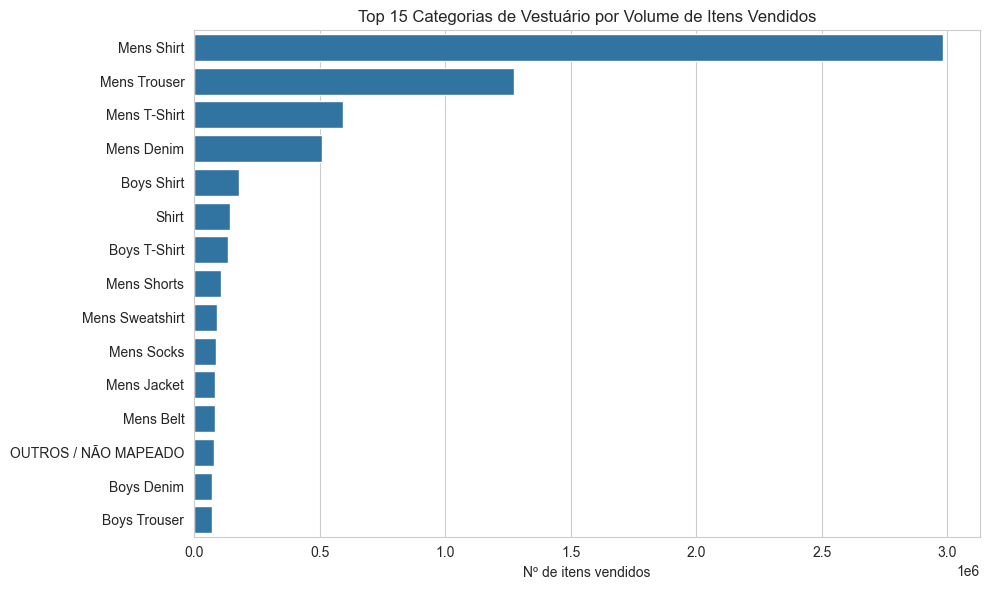

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

top_categorias = (
    df_clean[df_clean["is_apparel_v2"]]["category_clean"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categorias.values, y=top_categorias.index, orient="h")
plt.title("Top 15 Categorias de Vestuário por Volume de Itens Vendidos")
plt.xlabel("Nº de itens vendidos")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 23. Categorias de vestuário mais vendidas

O gráfico apresenta as principais categorias de vestuário por volume de itens vendidos. Essa visão destaca quais grupos de produtos possuem maior demanda e podem orientar decisões de estoque e planejamento comercial.

Percentil 99: $ 3436.83
Nº de itens acima do p99 (outliers visuais): 68430


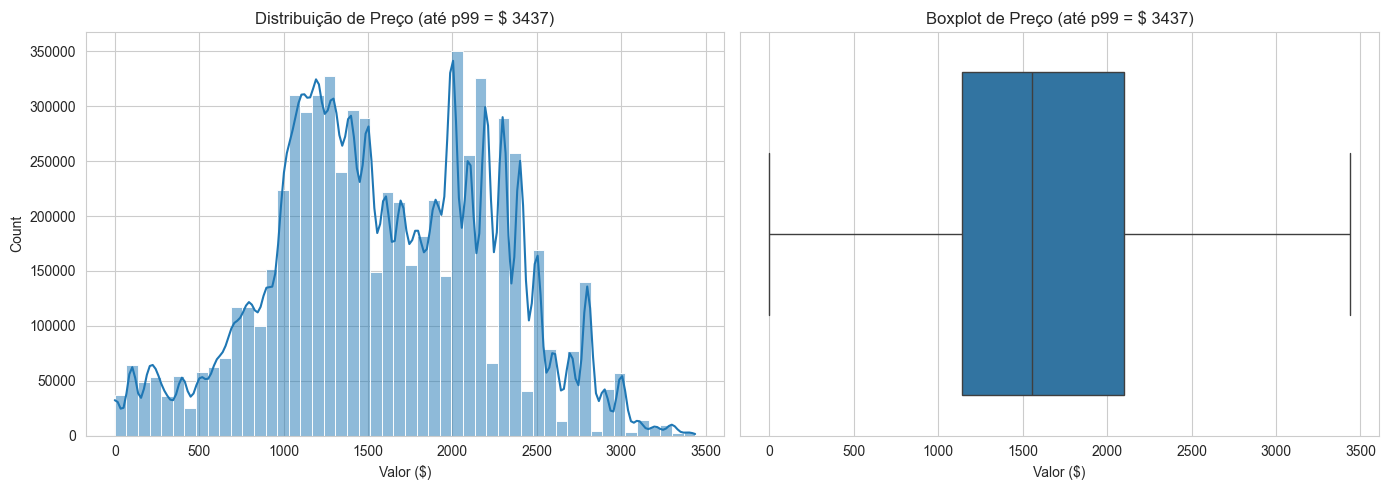


Describe
count    6.845577e+06
mean     1.634737e+03
std      7.692608e+02
min      0.000000e+00
25%      1.145840e+03
50%      1.574250e+03
75%      2.099000e+03
max      5.000000e+04
Name: line_item_amount, dtype: float64


In [67]:
apparel_price = df_clean[df_clean["is_apparel_v2"]]["line_item_amount"]

p99 = apparel_price.quantile(0.99)
print(f"Percentil 99: $ {p99:.2f}")
print(f"Nº de itens acima do p99 (outliers visuais): {(apparel_price > p99).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(apparel_price[apparel_price <= p99], bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"Distribuição de Preço (até p99 = $ {p99:.0f})")
axes[0].set_xlabel("Valor ($)")

sns.boxplot(x=apparel_price[apparel_price <= p99], ax=axes[1])
axes[1].set_title(f"Boxplot de Preço (até p99 = $ {p99:.0f})")
axes[1].set_xlabel("Valor ($)")

plt.tight_layout()
plt.show()

print("\nDescribe")
print(apparel_price.describe())

## 24. Distribuição de preços

A distribuição de `line_item_amount` é apresentada com foco nos valores até o percentil 99. A remoção visual dos extremos melhora a leitura do comportamento típico dos preços sem eliminar os registros da base analisada.

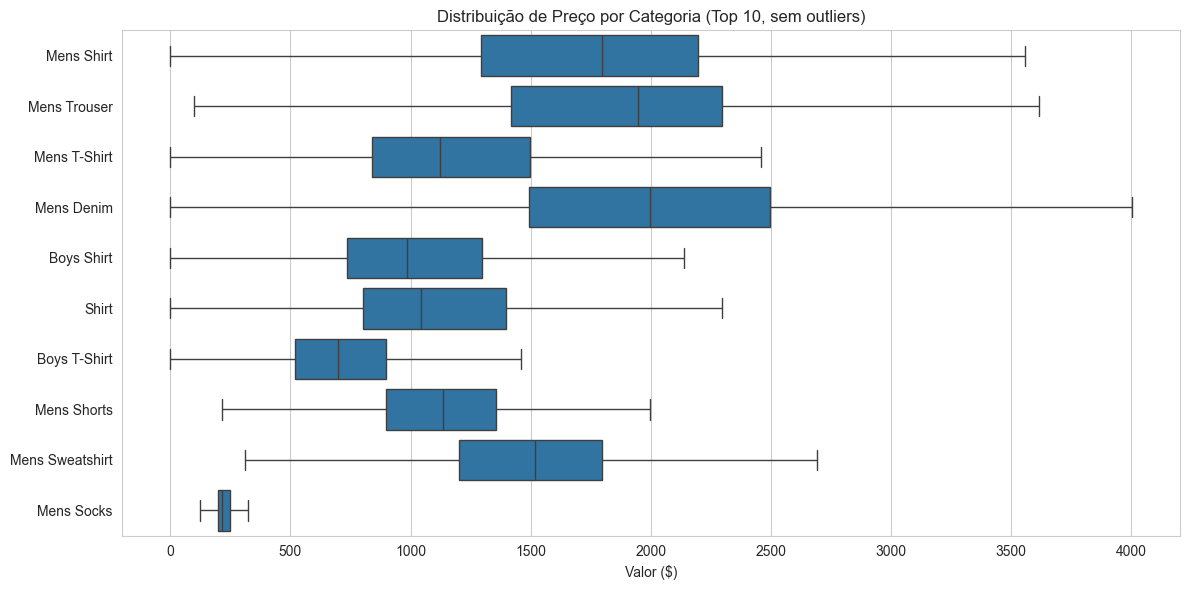

category_clean
Mens Denim         1999.0000
Mens Trouser       1949.0000
Mens Shirt         1799.0000
Mens Sweatshirt    1519.2000
Mens Shorts        1136.5438
Mens T-Shirt       1124.2500
Shirt              1045.0000
Boys Shirt          984.4815
Boys T-Shirt        699.0000
Mens Socks          214.3782
Name: line_item_amount, dtype: float64


In [68]:
top10_categorias = df_clean[df_clean["is_apparel_v2"]]["category_clean"].value_counts().head(10).index

df_top10 = df_clean[
    (df_clean["is_apparel_v2"]) & (df_clean["category_clean"].isin(top10_categorias))
]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_top10,
    x="line_item_amount",
    y="category_clean",
    order=top10_categorias,
    showfliers=False 
)
plt.title("Distribuição de Preço por Categoria (Top 10, sem outliers)")
plt.xlabel("Valor ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(df_top10.groupby("category_clean")["line_item_amount"].median().sort_values(ascending=False))

## 25. Preço por categoria

O boxplot compara a distribuição de preços das principais categorias de vestuário. A visualização evidencia que os grupos de produtos possuem faixas de preço, dispersões e valores medianos diferentes.

**Achado:** cada categoria apresenta um posicionamento de preço próprio, reforçando a importância de analisar o mix de produtos separadamente.

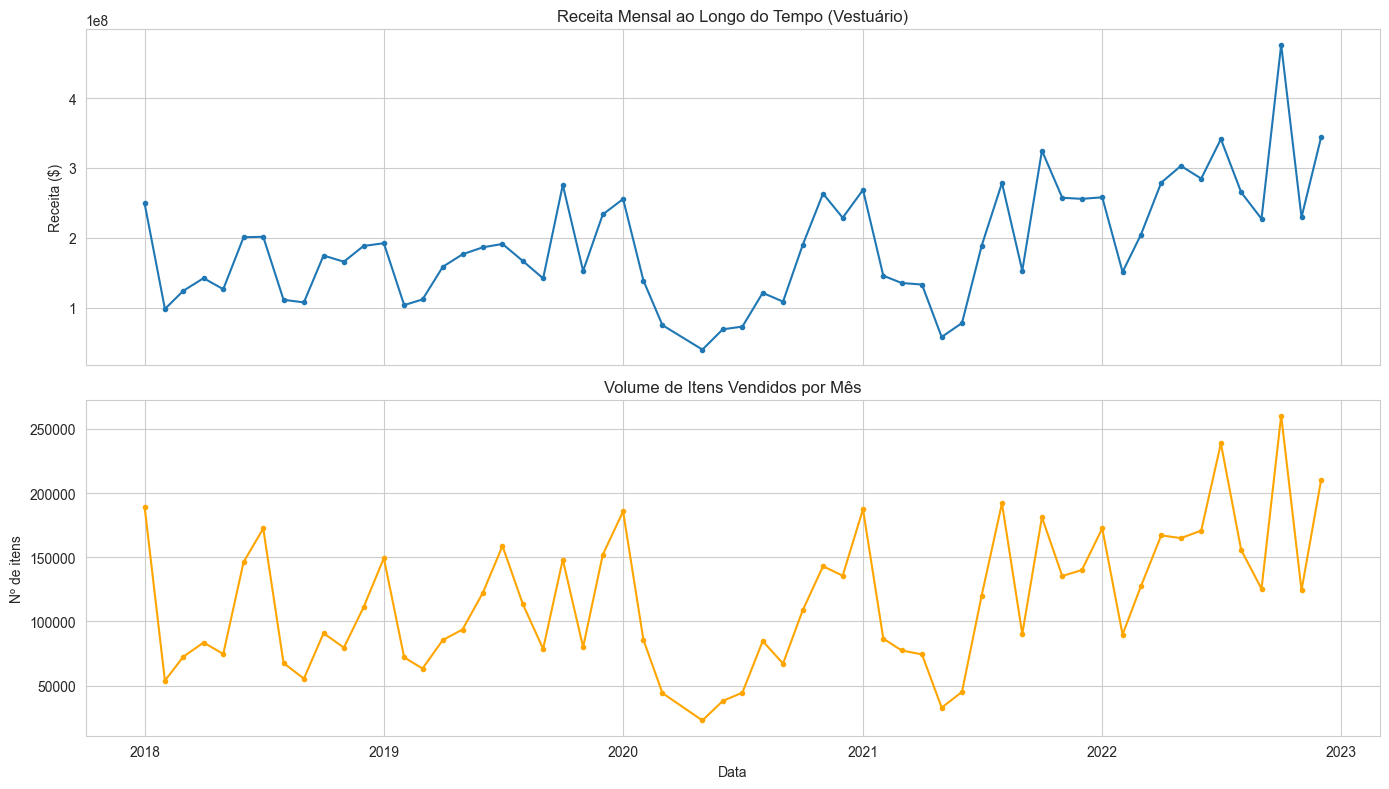

In [69]:
vendas_mensais = (
    df_clean[df_clean["is_apparel_v2"]]
    .groupby(df_clean["transaction_date"].dt.to_period("M"))
    .agg(receita=("line_item_amount", "sum"), qtd_itens=("line_item_amount", "count"))
    .reset_index()
)
vendas_mensais["transaction_date"] = vendas_mensais["transaction_date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(vendas_mensais["transaction_date"], vendas_mensais["receita"], marker="o", markersize=3)
axes[0].set_title("Receita Mensal ao Longo do Tempo (Vestuário)")
axes[0].set_ylabel("Receita ($)")

axes[1].plot(vendas_mensais["transaction_date"], vendas_mensais["qtd_itens"], marker="o", markersize=3, color="orange")
axes[1].set_title("Volume de Itens Vendidos por Mês")
axes[1].set_ylabel("Nº de itens")
axes[1].set_xlabel("Data")

plt.tight_layout()
plt.show()

## 26. Evolução mensal das vendas

São acompanhados mês a mês a receita e o volume de itens vendidos entre 2018 e 2022. Essa análise permite observar tendências de crescimento, períodos de retração e mudanças no ritmo comercial.

**Achado:** há uma queda associada ao período da pandemia, seguida por recuperação e crescimento nos anos posteriores.

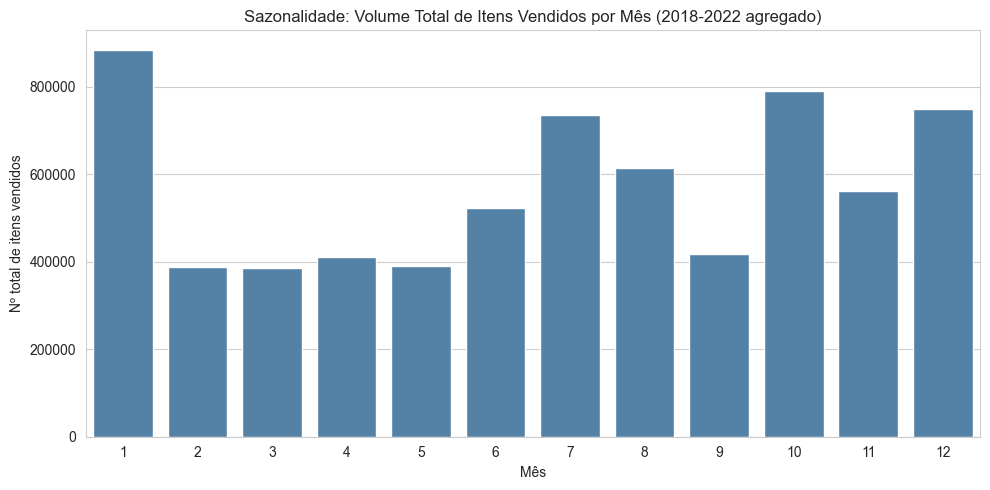

    month  receita_media  qtd_media
0       1   1.224078e+09     884098
9      10   1.441801e+09     789223
11     12   1.251079e+09     749116
6       7   9.959350e+08     734637
7       8   9.433677e+08     613484
10     11   1.068763e+09     562399
5       6   8.195875e+08     522520
8       9   7.387967e+08     417096
3       4   7.133721e+08     410624
4       5   7.043726e+08     389201
1       2   6.382301e+08     388190
2       3   6.513367e+08     384989


In [70]:
sazonalidade_mensal = (
    df_clean[(df_clean["is_apparel_v2"]) & (~df_clean["month"].isin([1,2,3]) | (df_clean["year"] != 2020))]
)

sazonalidade_mensal = (
    df_clean[df_clean["is_apparel_v2"]]
    .groupby("month")
    .agg(receita_media=("line_item_amount", "sum"), qtd_media=("line_item_amount", "count"))
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=sazonalidade_mensal, x="month", y="qtd_media", color="steelblue")
plt.title("Sazonalidade: Volume Total de Itens Vendidos por Mês (2018-2022 agregado)")
plt.xlabel("Mês")
plt.ylabel("Nº total de itens vendidos")
plt.tight_layout()
plt.show()

print(sazonalidade_mensal.sort_values("qtd_media", ascending=False))

## 27. Sazonalidade das vendas

O volume agregado é comparado entre os meses do ano para identificar padrões sazonais. Essa informação pode apoiar o planejamento de estoque, campanhas promocionais e alocação de equipes.

**Achado:** janeiro, outubro, dezembro e julho aparecem entre os períodos de maior movimento, enquanto outros meses apresentam demanda relativamente mais fraca.

           receita_total  qtd_itens  ticket_medio
zone_name                                        
South       7.299540e+09    4481842   1628.692014
North       1.435396e+09     859623   1669.797224
West        1.311568e+09     785784   1669.120393
East        8.858756e+08     515292   1719.172085
ROOT        2.132767e+08     175767   1213.405908
Central     4.506164e+07      27269   1652.485791


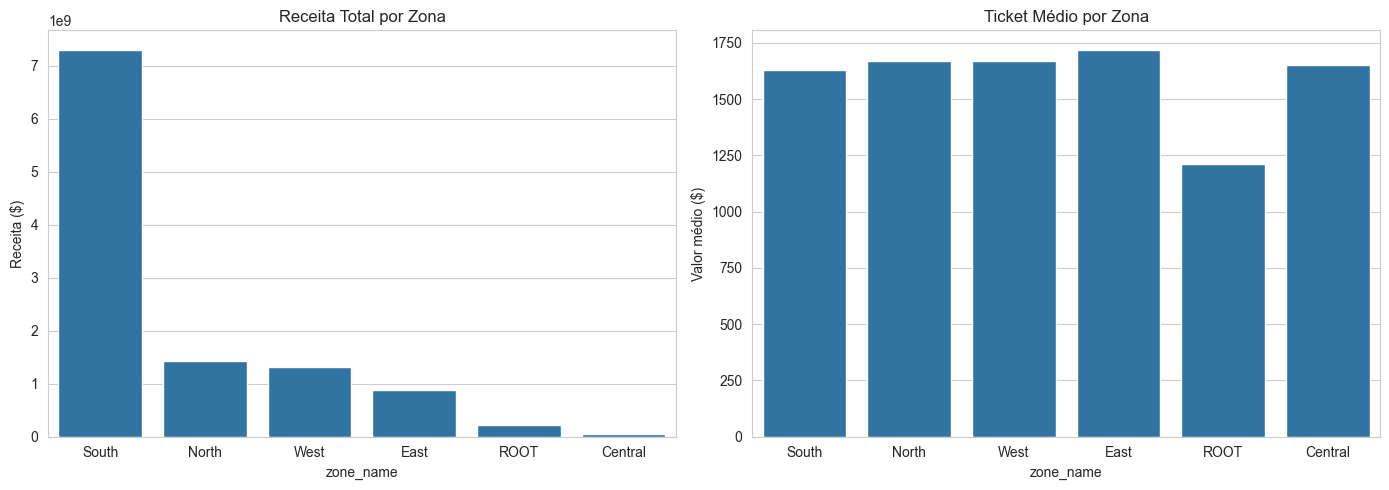

In [71]:
zona_analise = (
    df_clean[df_clean["is_apparel_v2"]]
    .groupby("zone_name")
    .agg(
        receita_total=("line_item_amount", "sum"),
        qtd_itens=("line_item_amount", "count"),
        ticket_medio=("line_item_amount", "mean")
    )
    .sort_values("receita_total", ascending=False)
)

print(zona_analise)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=zona_analise.index, y=zona_analise["receita_total"], ax=axes[0], order=zona_analise.index)
axes[0].set_title("Receita Total por Zona")
axes[0].set_ylabel("Receita ($)")

sns.barplot(x=zona_analise.index, y=zona_analise["ticket_medio"], ax=axes[1], order=zona_analise.index)
axes[1].set_title("Ticket Médio por Zona")
axes[1].set_ylabel("Valor médio ($)")

plt.tight_layout()
plt.show()

## 28. Desempenho por zona

A receita total, o volume de itens e o ticket médio são comparados entre as zonas de venda. A análise ajuda a separar o desempenho dos canais físicos do canal digital.

**Achado:** o canal e-commerce, identificado como `ROOT`, apresenta ticket médio aproximadamente 29% menor que o das lojas físicas, indicando diferenças relevantes no perfil de compra.

In [72]:
compras_por_cliente = (
    df_clean[df_clean["is_apparel_v2"]]
    .groupby("user_id")
    .agg(
        n_bills=("bill_id", "nunique"),
        total_gasto=("line_item_amount", "sum"),
    )
)

print(f"Total de clientes únicos: {len(compras_por_cliente)}")

faixas = pd.cut(compras_por_cliente["n_bills"], bins=[0, 1, 2, 5, 10, float("inf")],
                 labels=["1 visita", "2 visitas", "3-5 visitas", "6-10 visitas", "10+ visitas"])
print("\n% de clientes por faixa de recorrência:")
print((faixas.value_counts(normalize=True).sort_index() * 100).round(2))

Total de clientes únicos: 962026

% de clientes por faixa de recorrência:
n_bills
1 visita        67.94
2 visitas       15.73
3-5 visitas     11.10
6-10 visitas     3.44
10+ visitas      1.79
Name: proportion, dtype: float64


## 29. Recorrência dos clientes

Os clientes são agrupados conforme o número de visitas ou notas fiscais observadas. Essa segmentação mostra a proporção de compradores ocasionais e recorrentes, apoiando estratégias de retenção e relacionamento.

**Achado:** aproximadamente dois terços dos clientes compram apenas uma vez, indicando uma oportunidade importante para ações de recompra e fidelização.

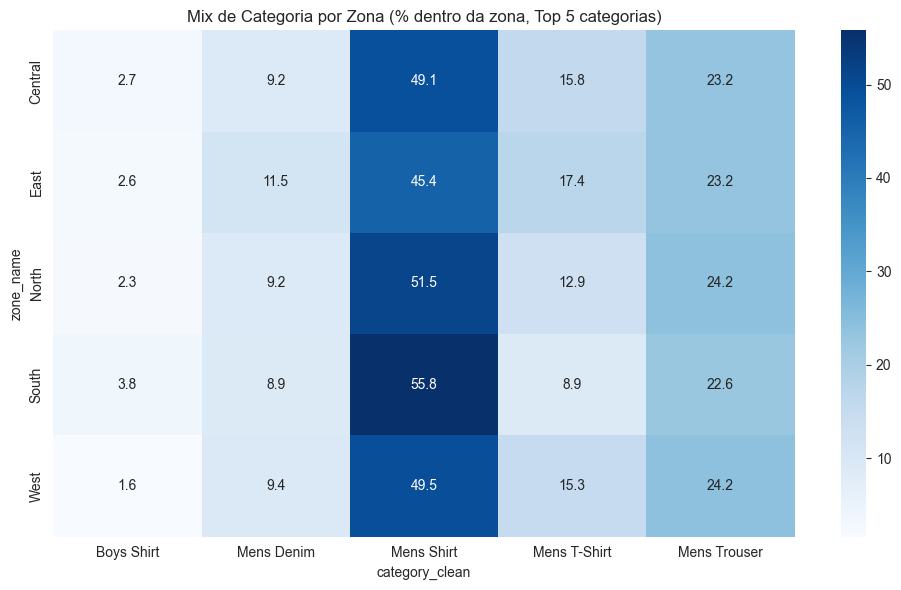

In [73]:
top5_categorias = df_clean[df_clean["is_apparel_v2"]]["category_clean"].value_counts().head(5).index

cross_zona_categoria = (
    df_clean[(df_clean["is_apparel_v2"]) & (df_clean["category_clean"].isin(top5_categorias))]
    .groupby(["zone_name", "category_clean"])
    .size()
    .unstack(fill_value=0)
)

cross_zona_pct = cross_zona_categoria.div(cross_zona_categoria.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(cross_zona_pct.round(1), annot=True, fmt=".1f", cmap="Blues")
plt.title("Mix de Categoria por Zona (% dentro da zona, Top 5 categorias)")
plt.tight_layout()
plt.show()

## 30. Mix de categorias por zona

O heatmap mostra a participação percentual das cinco principais categorias dentro de cada zona. Essa comparação revela diferenças no perfil de produtos vendidos entre regiões e canais.

A análise pode apoiar decisões de sortimento, reposição de estoque e campanhas direcionadas para cada zona.